# Sales Prediction and Customer Segmentation Analysis

**Nama:** Alya Salma Khoerunnisaa    
**Tugas:** Analisis Penjualan Chocolate Sales Dataset  

## Deskripsi Tugas
Pada tugas ini dilakukan analisis terhadap dataset penjualan cokelat untuk memahami pola penjualan dan perilaku pelanggan. Analisis dilakukan melalui beberapa tahapan yaitu data processing, exploratory data analysis, pembuatan model prediksi penjualan menggunakan metode regresi, serta segmentasi pelanggan menggunakan algoritma clustering.

Output utama yang diharapkan dari analisis ini adalah:
- **Sales Prediction (Regression Task)** untuk memprediksi revenue penjualan.
- **Customer Segmentation (Clustering)** untuk mengelompokkan pelanggan berdasarkan pola pembelian.

1. Import Library
Tahap pertama adalah mengimpor library yang akan digunakan untuk analisis data, visualisasi, dan pembuatan model machine learning.

Library yang digunakan:
- pandas → manipulasi data
- numpy → operasi numerik
- matplotlib & seaborn → visualisasi
- sklearn → machine learning (preprocessing, regression, clustering)

In [7]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.cluster import KMeans

2. Load Dataset
Dataset dibaca menggunakan pandas untuk melihat struktur data seperti jumlah baris, kolom, dan tipe data.

In [9]:
df = pd.read_csv("chocolate_sales_2025_dataset.csv")

df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sale_ID         500 non-null    int64  
 1   Date            500 non-null    object 
 2   Brand           500 non-null    object 
 3   Product_Type    500 non-null    object 
 4   Country         500 non-null    object 
 5   Sales_Channel   500 non-null    object 
 6   Payment_Method  500 non-null    object 
 7   Price_USD       500 non-null    float64
 8   Units_Sold      500 non-null    int64  
 9   Revenue_USD     500 non-null    float64
dtypes: float64(2), int64(2), object(6)
memory usage: 39.2+ KB


,Sale_ID,Price_USD,Units_Sold,Revenue_USD
count,500.000000,500.000000,500.000000,500.000000
mean,250.500000,13.779860,104.938000,1433.391140
std,144.481833,6.484013,56.263998,1065.679386
min,1.000000,2.520000,5.000000,20.480000
25%,125.750000,8.592500,56.750000,562.545000
50%,250.500000,13.480000,108.500000,1197.225000
75%,375.250000,19.445000,150.250000,2072.812500
max,500.000000,25.000000,200.000000,4809.260000


In [ ]:
## Data Processing

Pada tahap ini dilakukan proses pembersihan dan persiapan data sebelum digunakan dalam proses analisis dan pemodelan. Beberapa langkah yang dilakukan meliputi:

- Memeriksa adanya missing values pada dataset
- Mengubah tipe data pada kolom tanggal menjadi format datetime
- Mengubah data kategorikal menjadi bentuk numerik menggunakan label encoding
- Menyiapkan dataset agar dapat digunakan dalam proses modelling

Tahap ini penting untuk memastikan bahwa data yang digunakan sudah bersih dan sesuai untuk proses analisis selanjutnya.

3. Data Processing
    3.1 Cek Missing Values

Sebelum melakukan modelling, kita harus memastikan tidak ada data kosong yang dapat mempengaruhi performa model.

In [10]:
df.isnull().sum()

Sale_ID           0
Date              0
Brand             0
Product_Type      0
Country           0
Sales_Channel     0
Payment_Method    0
Price_USD         0
Units_Sold        0
Revenue_USD       0
dtype: int64

3.2 Konversi Tanggal

Kolom Date diubah menjadi format datetime agar bisa digunakan untuk analisis waktu.

In [12]:
df['Date'] = pd.to_datetime(df['Date'])

df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

3.3 Encoding Data Kategorikal

Machine learning tidak bisa membaca data berbentuk teks, sehingga kolom kategori perlu diubah menjadi angka menggunakan Label Encoding.

Kolom kategori:
- Brand
- Product_Type
- Country
- Sales_Channel
- Payment_Method

In [13]:
le = LabelEncoder()

categorical_cols = ['Brand','Product_Type','Country','Sales_Channel','Payment_Method']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

4. Exploratory Data Analysis (EDA)
4.1 Distribusi Revenue

Visualisasi ini menunjukkan distribusi pendapatan dari penjualan coklat.

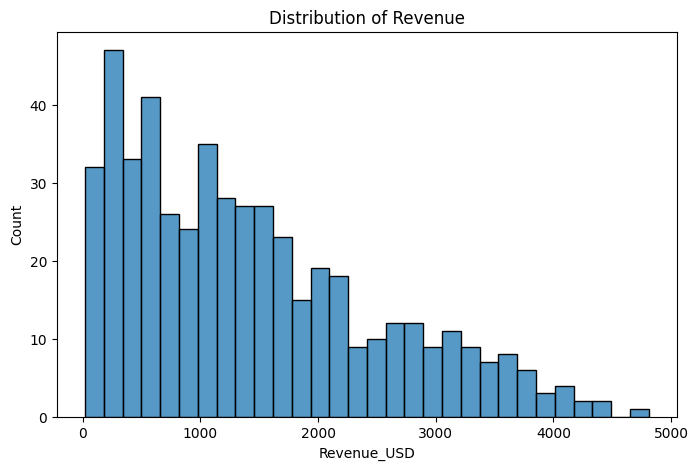

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(df['Revenue_USD'], bins=30)
plt.title("Distribution of Revenue")
plt.show()

4.2 Hubungan Price dan Revenue

Visualisasi ini melihat hubungan antara harga produk dan pendapatan yang dihasilkan.

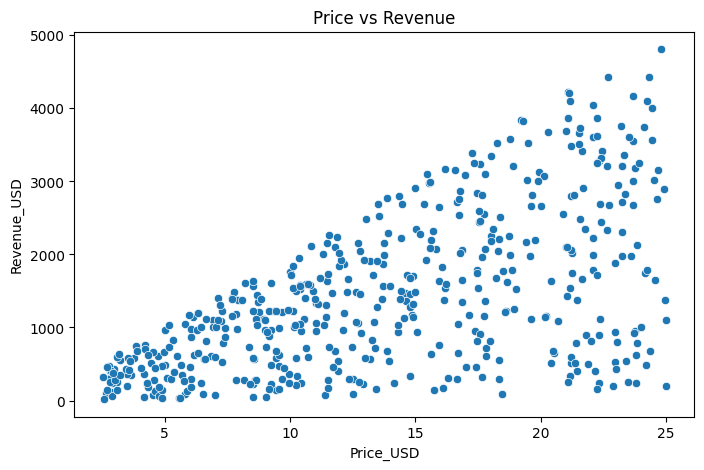

In [15]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['Price_USD'], y=df['Revenue_USD'])
plt.title("Price vs Revenue")
plt.show()

In [ ]:
## Sales Prediction using Regression

Pada tahap ini dilakukan pembuatan model machine learning untuk memprediksi nilai **Revenue_USD** berdasarkan beberapa fitur yang tersedia dalam dataset, seperti harga produk, jumlah unit terjual, brand, negara penjualan, channel penjualan, dan metode pembayaran.

Model yang digunakan dalam analisis ini adalah **Linear Regression**, yang merupakan salah satu metode regresi dasar untuk memprediksi nilai numerik.

Dataset dibagi menjadi dua bagian yaitu data training dan data testing untuk mengevaluasi performa model.

5. Sales Prediction (Regression)
5.1 Menentukan Feature dan Target

Dalam model regresi ini:

- Target (y): Revenue_USD

Feature (X):
- Brand
- Product_Type
- Country
- Sales_Channel
- Payment_Method
- Price_USD
- Units_Sold
- Month
- Day

In [16]:
X = df.drop(['Revenue_USD','Sale_ID','Date'], axis=1)
y = df['Revenue_USD']

5.2 Train Test Split

Dataset dibagi menjadi:
- 80% data training
- 20% data testing

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

5.3 Training Model

Model yang digunakan adalah Linear Regression, yaitu model dasar untuk memprediksi nilai kontinu.

In [18]:
model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


5.4 Prediction

Model digunakan untuk memprediksi revenue dari data testing

In [19]:
y_pred = model.predict(X_test)

6. Model Evaluation

Untuk mengevaluasi performa model digunakan:

- MAE (Mean Absolute Error)
- RMSE (Root Mean Square Error)
- R² Score
Semakin kecil error → semakin baik model.

In [20]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 298.5938186787729
RMSE: 402.3602298186344
R2 Score: 0.869189753599292


In [ ]:
## Customer Segmentation using Clustering

Selain melakukan prediksi penjualan, analisis ini juga bertujuan untuk mengelompokkan pelanggan berdasarkan pola pembelian mereka. Metode yang digunakan adalah **K-Means Clustering**, yang merupakan algoritma unsupervised learning untuk mengelompokkan data ke dalam beberapa cluster berdasarkan kemiripan karakteristik.

Fitur yang digunakan dalam proses clustering antara lain:
- Price_USD
- Units_Sold
- Revenue_USD

Jumlah cluster optimal ditentukan menggunakan **Elbow Method**.

7. Customer Segmentation (Clustering)

Clustering digunakan untuk mengelompokkan pola pembelian pelanggan berdasarkan karakteristik penjualan.
Fitur yang digunakan:
- Price_USD
- Units_Sold
- Revenue_USD
Metode yang digunakan adalah K-Means Clustering.

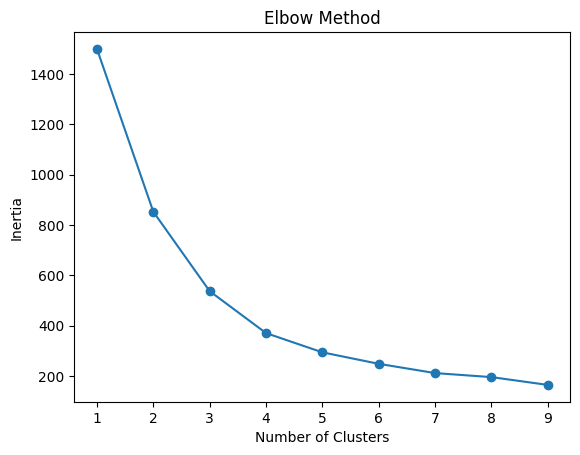

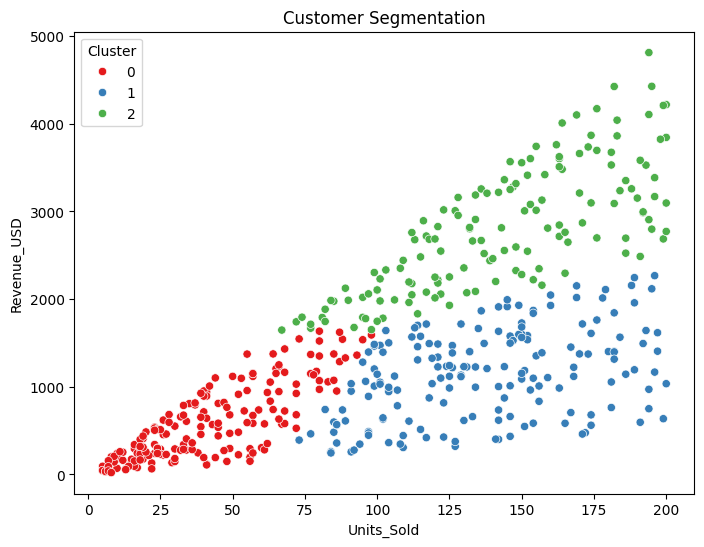

In [21]:
cluster_data = df[['Price_USD','Units_Sold','Revenue_USD']]
scaler = StandardScaler()

cluster_scaled = scaler.fit_transform(cluster_data)
inertia = []

K = range(1,10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(cluster_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(K, inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()
kmeans = KMeans(n_clusters=3, random_state=42)

df['Cluster'] = kmeans.fit_predict(cluster_scaled)
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df['Units_Sold'],
    y=df['Revenue_USD'],
    hue=df['Cluster'],
    palette='Set1'
)

plt.title("Customer Segmentation")
plt.show()

## Conclusion

Berdasarkan hasil analisis yang telah dilakukan, model regresi berhasil digunakan untuk memprediksi revenue penjualan cokelat berdasarkan beberapa fitur yang tersedia dalam dataset. Evaluasi model menunjukkan bahwa variabel seperti harga produk dan jumlah unit terjual memiliki pengaruh signifikan terhadap revenue penjualan.

Selain itu, segmentasi pelanggan menggunakan algoritma K-Means menghasilkan tiga kelompok pelanggan dengan karakteristik yang berbeda. Cluster pertama terdiri dari pelanggan dengan pembelian rendah, cluster kedua menunjukkan pelanggan dengan pembelian menengah, dan cluster ketiga merupakan pelanggan dengan pembelian tinggi yang memberikan kontribusi revenue terbesar.

Hasil analisis ini dapat membantu perusahaan dalam memahami pola penjualan serta menyusun strategi pemasaran yang lebih efektif berdasarkan segmentasi pelanggan.